# Comparision of different PRNGs (Model 2)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the histograms for model 2 shown in the report.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [9]:
df_MM1rho90 = pd.read_csv("statistics/results2MM1rho90.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1LogRho90 = pd.read_csv("statistics/results2MG1LogRho90.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1GammaRho90 = pd.read_csv("statistics/results2MG1GammaRho90.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MM1rho95 = pd.read_csv("statistics/results2MM1rho95.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1LogRho95 = pd.read_csv("statistics/results2MG1LogRho95.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1GammaRho95 = pd.read_csv("statistics/results2MG1GammaRho95.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")

In [10]:
generators=df_MM1rho90["rng_mode"].drop_duplicates().tolist()

### Colors for generator types

In [11]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

def color_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(color_from_name(label.get_text()))

def color_boxes(ax):
    for i, generator in enumerate(generators):
        c = color_from_name(generator)
        if c == 'black':
            continue
        ax.axvspan(0.5+i, 1.5+i, facecolor=c, alpha=0.1, edgecolor='none', zorder=-10)

def color_all(fig):
    axes = fig.axes
    for ax in axes:
        color_boxes(ax)
    color_labels(axes[-1])

## Generate boxplots for $\mathbf{E}[W]$ for the different models

In [12]:
EW1 = [(df_MM1rho90[df_MM1rho90["rng_mode"] == generator]["EW"] - 810) / 810 * 100 for generator in generators]
EW2 = [(df_MM1rho95[df_MM1rho95["rng_mode"] == generator]["EW"] - 1805) / 1805 * 100 for generator in generators]
EW3Log = [(df_MG1LogRho90[df_MG1LogRho90["rng_mode"] == generator]["EW"] - 506.25) / 506.25 * 100 for generator in generators]
EW3Gamma = [(df_MG1GammaRho90[df_MG1GammaRho90["rng_mode"] == generator]["EW"] - 506.25) / 506.25 * 100 for generator in generators]
EW4Log = [(df_MG1LogRho95[df_MG1LogRho95["rng_mode"] == generator]["EW"] - 1105) / 1105 * 100 for generator in generators]
EW4Gamma = [(df_MG1GammaRho95[df_MG1GammaRho95["rng_mode"] == generator]["EW"] - 1105) / 1105 * 100 for generator in generators]

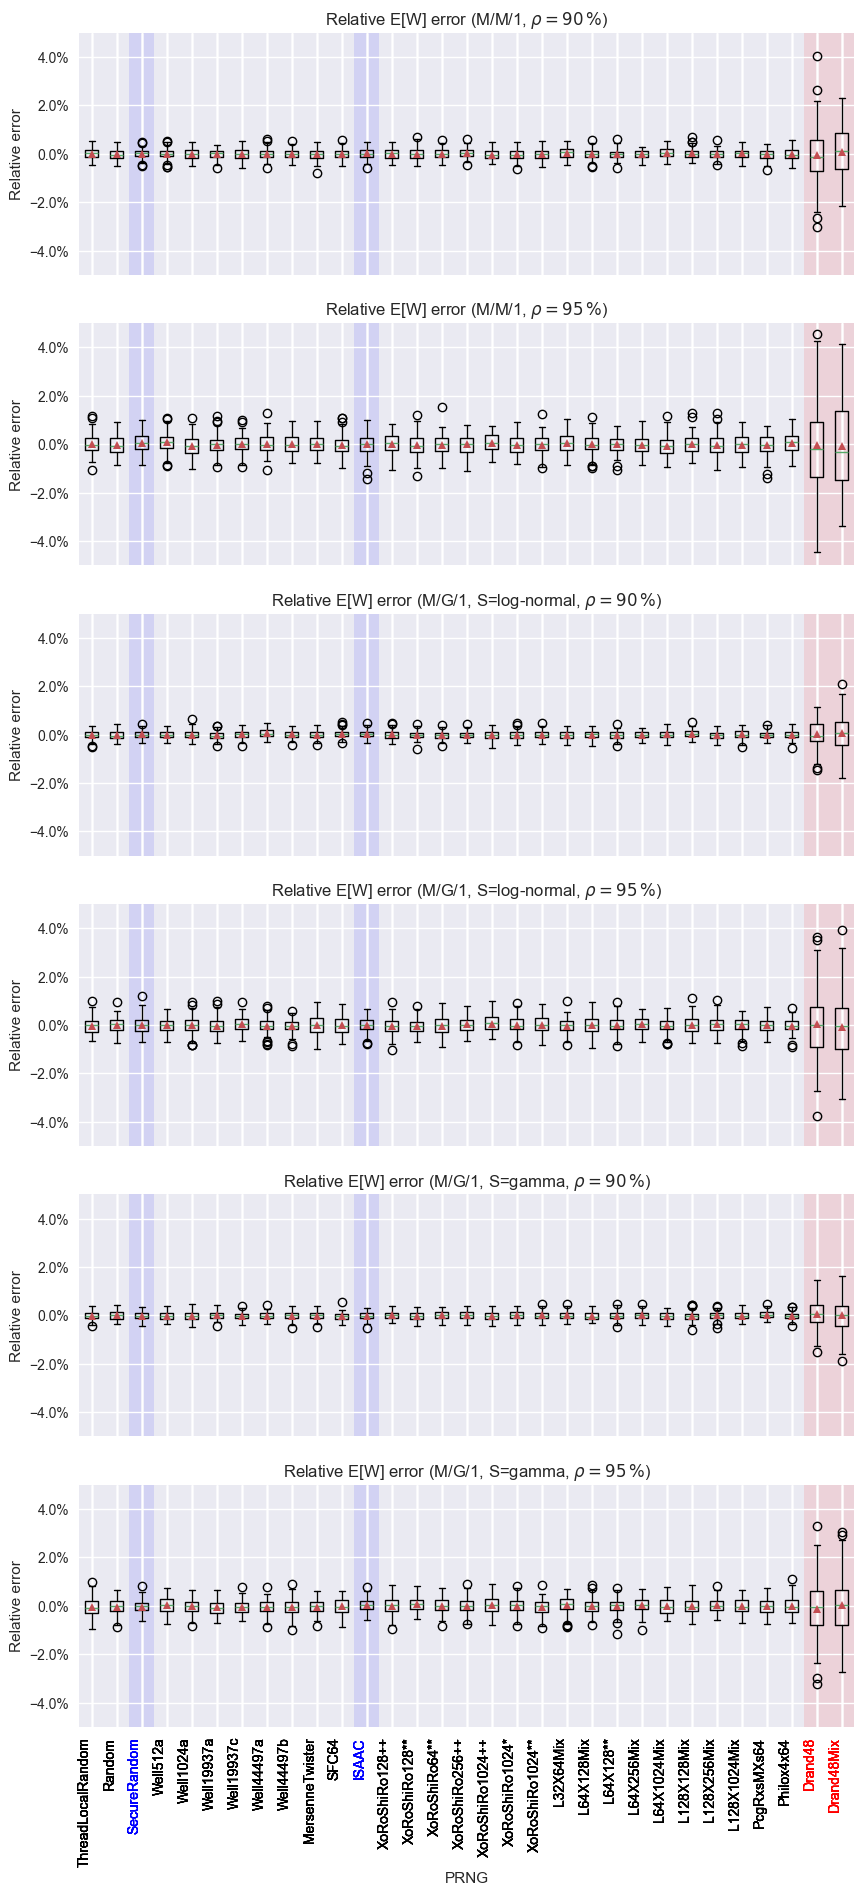

In [13]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(10, 22), sharey='row', sharex='col')

ax1.boxplot(EW1, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax2.boxplot(EW2, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax3.boxplot(EW3Log, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax4.boxplot(EW4Log, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax5.boxplot(EW3Gamma, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax6.boxplot(EW4Gamma, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore


ax1.set_title("Relative E[W] error (M/M/1, $\\rho=90\\,\\%$)")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative E[W] error (M/M/1, $\\rho=95\\,\\%$)")
ax2.set_ylabel("Relative error")

ax3.set_title("Relative E[W] error (M/G/1, S=log-normal, $\\rho=90\\,\\%$)")
ax3.set_ylabel("Relative error")

ax4.set_title("Relative E[W] error (M/G/1, S=log-normal, $\\rho=95\\,\\%$)")
ax4.set_ylabel("Relative error")

ax5.set_title("Relative E[W] error (M/G/1, S=gamma, $\\rho=90\\,\\%$)")
ax5.set_ylabel("Relative error")

ax6.set_title("Relative E[W] error (M/G/1, S=gamma, $\\rho=95\\,\\%$)")
ax6.set_ylabel("Relative error")

ax6.set_xlabel("PRNG")
ax6.set_xticklabels(generators + generators + generators + generators + generators + generators, rotation=90, ha='right')

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax5.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax6.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax1.set_ylim([-5, 5])
ax2.set_ylim([-5, 5])
ax3.set_ylim([-5, 5])
ax4.set_ylim([-5, 5])
ax5.set_ylim([-5, 5])
ax6.set_ylim([-5, 5])

color_all(fig)

# fig.savefig("plot2.png", format="png", bbox_inches='tight', pad_inches=0)

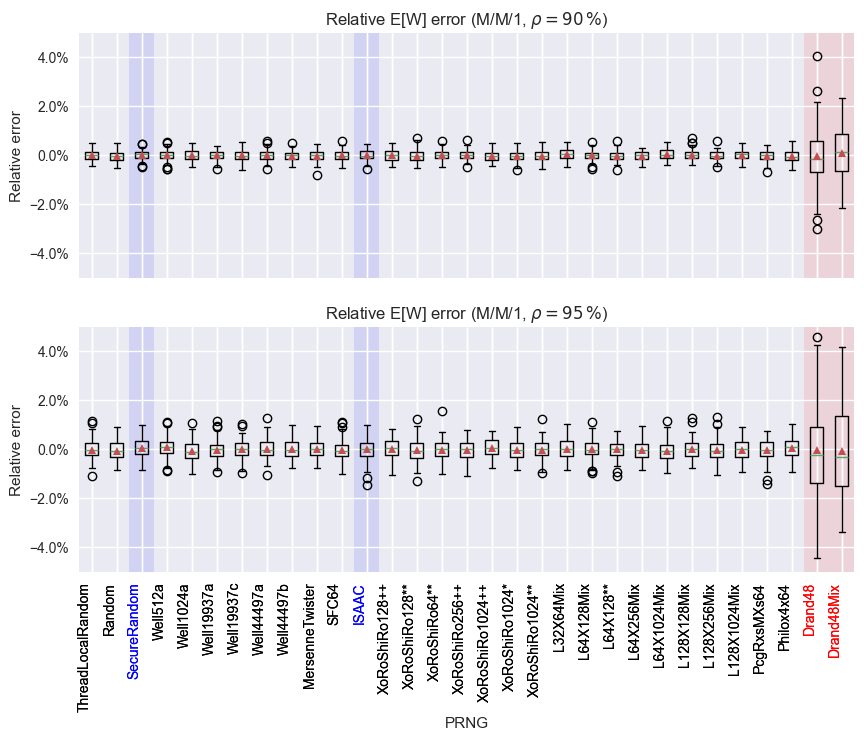

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharey='row', sharex='col')

ax1.boxplot(EW1, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax2.boxplot(EW2, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore

ax1.set_title("Relative E[W] error (M/M/1, $\\rho=90\\,\\%$)")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative E[W] error (M/M/1, $\\rho=95\\,\\%$)")
ax2.set_ylabel("Relative error")

ax2.set_xlabel("PRNG")
ax2.set_xticklabels(generators + generators, rotation=90, ha='right')

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax1.set_ylim([-5, 5])
ax2.set_ylim([-5, 5])

color_all(fig)

fig.savefig("PRNG-DES-Benchmarks-Figures-plot2-MM1.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

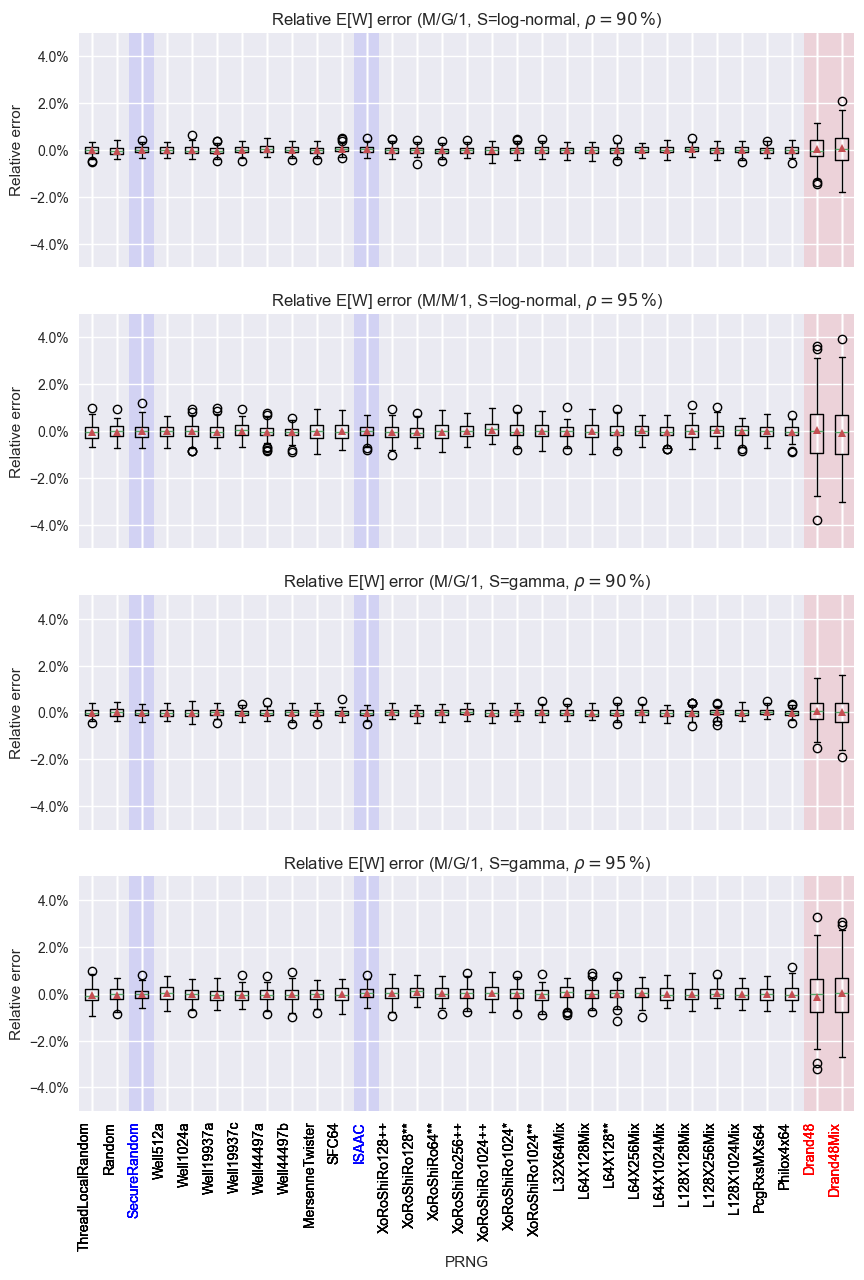

In [15]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 14), sharey='row', sharex='col')

ax1.boxplot(EW3Log, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax2.boxplot(EW4Log, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax3.boxplot(EW3Gamma, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax4.boxplot(EW4Gamma, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore

ax1.set_title("Relative E[W] error (M/G/1, S=log-normal, $\\rho=90\\,\\%$)")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative E[W] error (M/M/1, S=log-normal, $\\rho=95\\,\\%$)")
ax2.set_ylabel("Relative error")

ax3.set_title("Relative E[W] error (M/G/1, S=gamma, $\\rho=90\\,\\%$)")
ax3.set_ylabel("Relative error")

ax4.set_title("Relative E[W] error (M/G/1, S=gamma, $\\rho=95\\,\\%$)")
ax4.set_xlabel("PRNG")
ax4.set_ylabel("Relative error")
ax4.set_xticklabels(generators + generators + generators + generators, rotation=90, ha='right')

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax1.set_ylim([-5, 5])
ax2.set_ylim([-5, 5])
ax3.set_ylim([-5, 5])
ax4.set_ylim([-5, 5])

color_all(fig)

fig.savefig("PRNG-DES-Benchmarks-Figures-plot2-MG1.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

## Interquartile range

In [16]:
iqr_MM1_90=[]
iqr_MM1_95=[]
iqr_MG1Log_90=[]
iqr_MG1Log_95=[]
iqr_MG1Gamma_90=[]
iqr_MG1Gamma_95=[]

for i, generator in enumerate(generators):
    q1, q3 = np.quantile(EW1[i], [0.25, 0.75])
    iqr_MM1_90.append(q3 - q1)
    q1, q3 = np.quantile(EW2[i], [0.25, 0.75])
    iqr_MM1_95.append(q3 - q1)
    q1, q3 = np.quantile(EW3Log[i], [0.25, 0.75])
    iqr_MG1Log_90.append(q3 - q1)
    q1, q3 = np.quantile(EW4Log[i], [0.25, 0.75])
    iqr_MG1Log_95.append(q3 - q1)
    q1, q3 = np.quantile(EW3Gamma[i], [0.25, 0.75])
    iqr_MG1Gamma_90.append(q3 - q1)
    q1, q3 = np.quantile(EW4Gamma[i], [0.25, 0.75])
    iqr_MG1Gamma_95.append(q3 - q1)

df_iqr=pd.DataFrame({
    "M/M/1, rho=90%": iqr_MM1_90,
    "M/M/1, rho=95%": iqr_MM1_95,
    "M/G/1, (log), rho=90%": iqr_MG1Log_90,
    "M/G/1, (log), rho=95%": iqr_MG1Log_95,
    "M/G/1, (gamma), rho=90%": iqr_MG1Gamma_90,
    "M/G/1, (gamma), rho=95%": iqr_MG1Gamma_95
}, index=generators)


All values are percent points.

In [17]:
df_iqr

,"M/M/1, rho=90%","M/M/1, rho=95%","M/G/1, (log), rho=90%","M/G/1, (log), rho=95%","M/G/1, (gamma), rho=90%","M/G/1, (gamma), rho=95%"
ThreadLocalRandom,0.284721,0.491784,0.227531,0.453057,0.219437,0.503289
Random,0.282075,0.596726,0.247691,0.394687,0.272990,0.416293
SecureRandom,0.217465,0.514760,0.198358,0.438210,0.210792,0.315684
Well512a,0.233529,0.460753,0.224316,0.360364,0.227133,0.493512
Well1024a,0.325594,0.575425,0.233956,0.403833,0.253288,0.405800
Well19937a,0.256746,0.449905,0.196139,0.415739,0.207832,0.409366
Well19937c,0.299503,0.457881,0.214358,0.405614,0.199218,0.403871
Well44497a,0.249590,0.537085,0.263485,0.328752,0.202690,0.362560
Well44497b,0.236584,0.555465,0.210838,0.293939,0.235521,0.399591
MersenneTwister,0.278780,0.502042,0.213749,0.553561,0.203344,0.382449


### Maximum over all not-Drand generators

In [18]:
print("M/M/1, 90%:")
print(np.max(iqr_MM1_90[:-2]))
print("M/M/1, 95%:")
print(np.max(iqr_MM1_95[:-2]))
print("M/G/1, Log, 90%:")
print(np.max(iqr_MG1Log_90[:-2]))
print("M/G/1, Log, 95%:")
print(np.max(iqr_MG1Log_95[:-2]))
print("M/G/1, Gamma, 90%:")
print(np.max(iqr_MG1Gamma_90[:-2]))
print("M/G/1, Gamma, 95%:")
print(np.max(iqr_MG1Gamma_95[:-2]))

M/M/1, 90%:
0.34167027058911986
M/M/1, 95%:
0.5967255949769469
M/G/1, Log, 90%:
0.28283685576482437
M/G/1, Log, 95%:
0.5599685040991265
M/G/1, Gamma, 90%:
0.2729901467628393
M/G/1, Gamma, 95%:
0.5154550661560058


## Generate table for mean errors (not used in the report)

In [19]:
d = {}

df = df_MM1rho90
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 810) / 810 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 900) / 900 * 100, 5))
d["E[W] - MM1"] = EW_error
d["E[V] - MM1"] = EV_error

df = df_MG1LogRho90
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1Log"] = EW_error
d["E[V] - MG1Log"] = EV_error

df = df_MG1GammaRho90
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1Gamma"] = EW_error
d["E[V] - MG1Gamma"] = EV_error

df_mean = pd.DataFrame(d, index=generators)

df_mean

,E[W] - MM1,E[V] - MM1,E[W] - MG1Log,E[V] - MG1Log,E[W] - MG1Gamma,E[V] - MG1Gamma
ThreadLocalRandom,0.01406,0.01264,0.00785,0.00665,0.00327,0.00274
Random,0.02091,0.01887,0.02623,0.02232,0.01159,0.00982
SecureRandom,0.01210,0.01098,0.01822,0.01553,0.00828,0.00712
Well512a,0.00558,0.00512,0.00154,0.00145,0.01059,0.00893
Well1024a,0.00191,0.00174,0.00916,0.00778,0.01132,0.00956
Well19937a,0.00598,0.00542,0.02446,0.02083,0.02338,0.01985
Well19937c,0.00333,0.00324,0.01178,0.01004,0.02078,0.01761
Well44497a,0.00545,0.00494,0.04793,0.04076,0.00462,0.00400
Well44497b,0.00916,0.00830,0.01003,0.00867,0.01345,0.01150
MersenneTwister,0.01900,0.01705,0.00176,0.00141,0.00531,0.00450


In [20]:

s = df_mean.style.format("{:.3f}\\,\\%").set_caption("Mean Error (in \\%)").set_table_styles([{
    "selector": "caption",
    "props": []
}])
print(s.to_latex())

\begin{table}
\caption{Mean Error (in \%)}
\begin{tabular}{lrrrrrr}
 & E[W] - MM1 & E[V] - MM1 & E[W] - MG1Log & E[V] - MG1Log & E[W] - MG1Gamma & E[V] - MG1Gamma \\
ThreadLocalRandom & 0.014\,\% & 0.013\,\% & 0.008\,\% & 0.007\,\% & 0.003\,\% & 0.003\,\% \\
Random & 0.021\,\% & 0.019\,\% & 0.026\,\% & 0.022\,\% & 0.012\,\% & 0.010\,\% \\
SecureRandom & 0.012\,\% & 0.011\,\% & 0.018\,\% & 0.016\,\% & 0.008\,\% & 0.007\,\% \\
Well512a & 0.006\,\% & 0.005\,\% & 0.002\,\% & 0.001\,\% & 0.011\,\% & 0.009\,\% \\
Well1024a & 0.002\,\% & 0.002\,\% & 0.009\,\% & 0.008\,\% & 0.011\,\% & 0.010\,\% \\
Well19937a & 0.006\,\% & 0.005\,\% & 0.024\,\% & 0.021\,\% & 0.023\,\% & 0.020\,\% \\
Well19937c & 0.003\,\% & 0.003\,\% & 0.012\,\% & 0.010\,\% & 0.021\,\% & 0.018\,\% \\
Well44497a & 0.005\,\% & 0.005\,\% & 0.048\,\% & 0.041\,\% & 0.005\,\% & 0.004\,\% \\
Well44497b & 0.009\,\% & 0.008\,\% & 0.010\,\% & 0.009\,\% & 0.013\,\% & 0.011\,\% \\
MersenneTwister & 0.019\,\% & 0.017\,\% & 0.002\,\% & 0.00

In [21]:
s = df_mean.style.format("{:.3f}%").set_caption("Mean Error (in \\%)")
print(s.to_html())

<style type="text/css">
</style>
<table id="T_4ef1e">
  <caption>Mean Error (in \%)</caption>
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_4ef1e_level0_col0" class="col_heading level0 col0" >E[W] - MM1</th>
      <th id="T_4ef1e_level0_col1" class="col_heading level0 col1" >E[V] - MM1</th>
      <th id="T_4ef1e_level0_col2" class="col_heading level0 col2" >E[W] - MG1Log</th>
      <th id="T_4ef1e_level0_col3" class="col_heading level0 col3" >E[V] - MG1Log</th>
      <th id="T_4ef1e_level0_col4" class="col_heading level0 col4" >E[W] - MG1Gamma</th>
      <th id="T_4ef1e_level0_col5" class="col_heading level0 col5" >E[V] - MG1Gamma</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_4ef1e_level0_row0" class="row_heading level0 row0" >ThreadLocalRandom</th>
      <td id="T_4ef1e_row0_col0" class="data row0 col0" >0.014%</td>
      <td id="T_4ef1e_row0_col1" class="data row0 col1" >0.013%</td>
      <td id="T_4ef1e_row0_col2" class="data row0 col2

In [22]:
d = {}

df = df_MM1rho95
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 810) / 810 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 900) / 900 * 100, 5))
d["E[W] - MM1"] = EW_error
d["E[V] - MM1"] = EV_error

df = df_MG1LogRho95
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1Log"] = EW_error
d["E[V] - MG1Log"] = EV_error

df = df_MG1GammaRho95
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1Gamma"] = EW_error
d["E[V] - MG1Gamma"] = EV_error

df_mean = pd.DataFrame(d, index=generators)

df_mean

,E[W] - MM1,E[V] - MM1,E[W] - MG1Log,E[V] - MG1Log,E[W] - MG1Gamma,E[V] - MG1Gamma
ThreadLocalRandom,122.82283,111.09604,118.20937,101.20497,118.15711,101.16056
Random,122.72917,111.01162,118.24659,101.23654,118.19243,101.19070
SecureRandom,122.96241,111.22177,118.26456,101.25180,118.21051,101.20592
Well512a,123.06004,111.30963,118.25211,101.24120,118.36327,101.33560
Well1024a,122.71824,111.00194,118.25359,101.24249,118.24325,101.23365
Well19937a,122.80741,111.08227,118.21784,101.21222,118.13994,101.14602
Well19937c,122.89749,111.16355,118.33847,101.31466,118.14116,101.14708
Well44497a,122.86457,111.13376,118.22057,101.21444,118.21012,101.20560
Well44497b,122.89121,111.15777,118.16683,101.16889,118.20000,101.19687
MersenneTwister,122.85988,111.12931,118.24632,101.23653,118.20387,101.20035


In [23]:

s = df_mean.style.format("{:.3f}\\,\\%").set_caption("Mean Error (in \\%)").set_table_styles([{
    "selector": "caption",
    "props": []
}])
print(s.to_latex())

\begin{table}
\caption{Mean Error (in \%)}
\begin{tabular}{lrrrrrr}
 & E[W] - MM1 & E[V] - MM1 & E[W] - MG1Log & E[V] - MG1Log & E[W] - MG1Gamma & E[V] - MG1Gamma \\
ThreadLocalRandom & 122.823\,\% & 111.096\,\% & 118.209\,\% & 101.205\,\% & 118.157\,\% & 101.161\,\% \\
Random & 122.729\,\% & 111.012\,\% & 118.247\,\% & 101.237\,\% & 118.192\,\% & 101.191\,\% \\
SecureRandom & 122.962\,\% & 111.222\,\% & 118.265\,\% & 101.252\,\% & 118.211\,\% & 101.206\,\% \\
Well512a & 123.060\,\% & 111.310\,\% & 118.252\,\% & 101.241\,\% & 118.363\,\% & 101.336\,\% \\
Well1024a & 122.718\,\% & 111.002\,\% & 118.254\,\% & 101.242\,\% & 118.243\,\% & 101.234\,\% \\
Well19937a & 122.807\,\% & 111.082\,\% & 118.218\,\% & 101.212\,\% & 118.140\,\% & 101.146\,\% \\
Well19937c & 122.897\,\% & 111.164\,\% & 118.338\,\% & 101.315\,\% & 118.141\,\% & 101.147\,\% \\
Well44497a & 122.865\,\% & 111.134\,\% & 118.221\,\% & 101.214\,\% & 118.210\,\% & 101.206\,\% \\
Well44497b & 122.891\,\% & 111.158\,\% & 118.167

In [24]:
s = df_mean.style.format("{:.3f}%").set_caption("Mean Error (in \\%)")
print(s.to_html())

<style type="text/css">
</style>
<table id="T_c47fa">
  <caption>Mean Error (in \%)</caption>
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_c47fa_level0_col0" class="col_heading level0 col0" >E[W] - MM1</th>
      <th id="T_c47fa_level0_col1" class="col_heading level0 col1" >E[V] - MM1</th>
      <th id="T_c47fa_level0_col2" class="col_heading level0 col2" >E[W] - MG1Log</th>
      <th id="T_c47fa_level0_col3" class="col_heading level0 col3" >E[V] - MG1Log</th>
      <th id="T_c47fa_level0_col4" class="col_heading level0 col4" >E[W] - MG1Gamma</th>
      <th id="T_c47fa_level0_col5" class="col_heading level0 col5" >E[V] - MG1Gamma</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_c47fa_level0_row0" class="row_heading level0 row0" >ThreadLocalRandom</th>
      <td id="T_c47fa_row0_col0" class="data row0 col0" >122.823%</td>
      <td id="T_c47fa_row0_col1" class="data row0 col1" >111.096%</td>
      <td id="T_c47fa_row0_col2" class="data row0 